<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


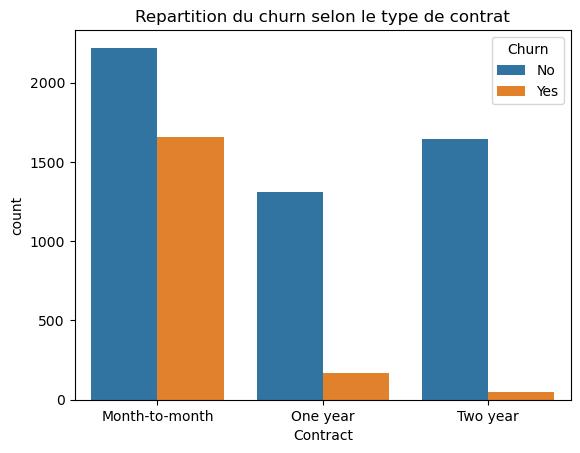

   Contract_One year  Contract_Two year  InternetService_Fiber optic  \
0              False              False                        False   
1               True              False                        False   
2              False              False                        False   
3               True              False                        False   
4              False              False                         True   

   InternetService_No  
0               False  
1               False  
2               False  
3               False  
4               False  
--- VRAIE MATRICE DE CONFUSION ---
[[747 288]
 [ 81 293]]

--- VRAI RAPPORT DE CLASSIFICATION ---
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

import numpy as np

import seaborn as sns

from sklearn.model_selection import train_test_split,cross_val_score

from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

from sklearn.ensemble import RandomForestClassifier

import joblib


df_dep=pd.read_csv('/Users/client/projet_ml/Telco-Customer-Churn.csv')

df_dep.columns

df_dep.info()

df_dep['TotalCharges']=pd.to_numeric(df_dep['TotalCharges'],errors='coerce')
df_dep.isnull().sum()
#analyser la variables totalcharges
df_dep['TotalCharges'].describe()
# j ai vu que la distrubution n est pas  normale  donc je peux imputer par la moyenne
df_dep['TotalCharges']=df_dep['TotalCharges'].fillna(0)
df_dep['TotalCharges'].isnull().sum()

sns.countplot(data=df_dep,x='Contract',hue='Churn')
plt.title('Repartition du churn selon le type de contrat')
plt.show()

#je vois que le nombre de clients partis sont plus celles qui  ont le contrat month_to_month 

df_dep['Churn_numeric'] = df_dep['Churn'].map({'Yes': 1, 'No': 0})
numerics=df_dep.select_dtypes(include=['number'])
corres=numerics.corr()['Churn_numeric'].sort_values(ascending=False)
corres

colonnes_test = ['Contract', 'InternetService']
df_encoded = pd.get_dummies(df_dep[colonnes_test], drop_first=True)

print(df_encoded.head())



df_model = df_dep.drop(columns=['customerID', 'Churn', 'Churn_numeric'], errors='ignore')

X = pd.get_dummies(df_model, drop_first=True, dtype=int)
y = df_dep['Churn_numeric']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])


model_client = LogisticRegression(max_iter=1000,class_weight='balanced')
model_client.fit(X_train_scaled, y_train)

y_pred = model_client.predict(X_test_scaled)

print("--- VRAIE MATRICE DE CONFUSION ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- VRAI RAPPORT DE CLASSIFICATION ---")
print(classification_report(y_test, y_pred))

model_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)


model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)


print("--- RAPPORT DE CLASSIFICATION : RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))



joblib.dump(model_client, 'modele_churn_telecom.pkl')


joblib.dump(scaler, 'scaler_churn.pkl')

print("Modèle et Scaler sauvegardés avec succès ! En route pour la production.")